# 🛡️ Phase 2 — CVE Forecasting: Deep Learning Extension

**Project:** Forecasting Cyber-Attacks and Modeling Threat Trends using Machine Learning  
**Phase:** 2 of 4  
**Models:** Multivariate LSTM · BiLSTM · Transformer  
**Data source:** Phase 1 output cache (`daily_cve_timeseries.csv`)  

---

### What Phase 2 does
Phase 1 established baseline forecasts with ARIMA, Random Forest, XGBoost, SVR, and a **univariate** LSTM (single input channel: raw CVE count).  
Phase 2 upgrades the deep learning component by feeding **all 10 engineered features** simultaneously into three architectures:

| Model | Key idea |
|---|---|
| **Multivariate LSTM** | Direct upgrade of Phase 1 LSTM — 10 input channels instead of 1 |
| **BiLSTM** | Processes the 14-day window forward **and** backward |
| **Transformer** | Self-attention over the 14-day window — no recurrence |

Results are merged with Phase 1 metrics for a combined 8-model comparison.

---

### Roadmap
| Phase | Focus | Status |
|---|---|---|
| Phase 1 | Baseline — ARIMA, RF, XGBoost, SVR, univariate LSTM | ✅ Done |
| **Phase 2** | **Deep Learning — Multivariate LSTM, BiLSTM, Transformer** | ▶️ This notebook |
| Phase 3 | Graph Neural Network (B-MTGNN) | 🔜 |
| Phase 4 | Threat-Defence Gap + Power BI Dashboard | 🔜 |


---
## ⚙️ Step 1 — Install & Import Libraries


In [1]:
# Install / upgrade if needed — uncomment the line below on first run
# !pip install --upgrade tensorflow numpy pandas matplotlib seaborn scikit-learn

import warnings
warnings.filterwarnings('ignore')

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from datetime import datetime, timedelta
from pathlib import Path

# Scikit-learn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    LSTM, Bidirectional, Dense, Dropout,
    Input, LayerNormalization, MultiHeadAttention,
    GlobalAveragePooling1D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# ── Version checks
print(f'  TensorFlow : {tf.__version__}')
print(f'  NumPy      : {np.__version__}')
print(f'  Pandas     : {pd.__version__}')

major, minor = [int(x) for x in tf.__version__.split('.')[:2]]
assert major > 2 or (major == 2 and minor >= 4), \
    'Phase 2 requires TensorFlow >= 2.4 (for MultiHeadAttention). Run: pip install --upgrade tensorflow'
print('  All library checks passed ✅')


  TensorFlow : 2.21.0
  NumPy      : 2.2.0
  Pandas     : 2.2.3
  All library checks passed ✅


---
## 🗂️ Step 2 — Configuration


Phase 2 reads Phase 1's cache files from this directory and writes its own outputs into a `phase2/` subdirectory.


In [2]:
# ─────────────────────────────────────────────────────────────────────
# UPDATE THIS PATH to match your Phase 1 OUTPUT_DIR
# ─────────────────────────────────────────────────────────────────────
OUTPUT_DIR = Path(r'C:\Users\imved\OneDrive\Desktop\cysecc\cybersec-ind\baseline_outputs')   # ← change this

# Phase 2 writes all outputs here (created automatically)
P2_DIR = OUTPUT_DIR / 'phase2'
P2_DIR.mkdir(parents=True, exist_ok=True)

# ── Constants (must match Phase 1 for comparability)
LOOK_BACK   = 14       # sliding-window size in days
TRAIN_RATIO = 0.80     # 80/20 split
YEARS_BACK  = 3        # most recent N years
RANDOM_SEED = 42

FEATURES = [
    'day_of_week', 'month', 'day_of_year', 'week_of_year',
    'is_weekend', 'quarter',
    'rolling_7d_mean', 'rolling_14d_mean',
    'lag_1', 'lag_7'
]
N_FEATURES = len(FEATURES)   # 10

# ── Plot colours (extend Phase 1 palette)
COLORS = {
    'actual'     : '#2C3E50',
    'mv_lstm'    : '#1ABC9C',
    'bilstm'     : '#E67E22',
    'transformer': '#9B59B6',
    'arima'      : '#E74C3C',
    'rf'         : '#2ECC71',
    'xgb'        : '#3498DB',
    'svr'        : '#95A5A6',
    'lstm_p1'    : '#F39C12',
}

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid']      = True
plt.rcParams['grid.alpha']     = 0.3
sns.set_palette('husl')

tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f'  OUTPUT_DIR : {OUTPUT_DIR}')
print(f'  P2_DIR     : {P2_DIR}')
print(f'  LOOK_BACK  : {LOOK_BACK} days')
print(f'  Features   : {N_FEATURES}  → {FEATURES}')


  OUTPUT_DIR : C:\Users\imved\OneDrive\Desktop\cysecc\cybersec-ind\baseline_outputs
  P2_DIR     : C:\Users\imved\OneDrive\Desktop\cysecc\cybersec-ind\baseline_outputs\phase2
  LOOK_BACK  : 14 days
  Features   : 10  → ['day_of_week', 'month', 'day_of_year', 'week_of_year', 'is_weekend', 'quarter', 'rolling_7d_mean', 'rolling_14d_mean', 'lag_1', 'lag_7']


---
## 📥 Step 3 — Load Phase 1 Data


Phase 2 reads directly from Phase 1's cached outputs — no re-parsing of the 335K CVE JSON files.  

**Priority:**  
1. `daily_cve_timeseries.csv` — fastest, all features pre-computed  
2. `cve_parsed.csv` — fallback, features are recomputed  
3. Neither found → `FileNotFoundError` (run Phase 1 first)


In [3]:
def _add_features(df: pd.DataFrame) -> pd.DataFrame:
    """Recompute all 10 temporal + lag features (same logic as Phase 1)."""
    df = df.copy()
    df['day_of_week']     = df['date'].dt.dayofweek
    df['month']           = df['date'].dt.month
    df['day_of_year']     = df['date'].dt.dayofyear
    df['week_of_year']    = df['date'].dt.isocalendar().week.astype(int)
    df['is_weekend']      = (df['day_of_week'] >= 5).astype(int)
    df['quarter']         = df['date'].dt.quarter
    df['rolling_7d_mean'] = df['cve_count'].rolling(7,  min_periods=1).mean()
    df['rolling_14d_mean']= df['cve_count'].rolling(14, min_periods=1).mean()
    df['lag_1']           = df['cve_count'].shift(1)
    df['lag_7']           = df['cve_count'].shift(7)
    df.bfill(inplace=True)
    return df


def load_phase1_timeseries() -> pd.DataFrame:
    ts_cache  = OUTPUT_DIR / 'daily_cve_timeseries.csv'
    raw_cache = OUTPUT_DIR / 'cve_parsed.csv'

    if ts_cache.exists():
        print(f'  Loading from: {ts_cache}')
        df = pd.read_csv(ts_cache, parse_dates=['date'])
        df = df.sort_values('date').reset_index(drop=True)
        missing = [f for f in FEATURES if f not in df.columns]
        if missing:
            print(f'  Recomputing missing features: {missing}')
            df = _add_features(df)
        print(f'  Loaded {len(df):,} daily records  '
              f'({df["date"].min().date()} → {df["date"].max().date()})')
        return df

    elif raw_cache.exists():
        print(f'  Fallback: rebuilding from {raw_cache}')
        raw = pd.read_csv(raw_cache, on_bad_lines='skip')
        raw['date_published'] = pd.to_datetime(
            raw['date_published'], errors='coerce', utc=True
        ).dt.tz_localize(None)
        raw = raw.dropna(subset=['date_published'])
        raw['date'] = raw['date_published'].dt.date
        df = raw.groupby('date').size().reset_index(name='cve_count')
        df['date'] = pd.to_datetime(df['date'])
        df = df.sort_values('date').reset_index(drop=True)
        df = _add_features(df)
        print(f'  Rebuilt {len(df):,} daily records.')
        return df

    else:
        raise FileNotFoundError(
            'No Phase 1 cache found.\n'
            f'Expected: {ts_cache}\nor: {raw_cache}\n'
            'Run phase1_cve_baseline.py first.'
        )


In [4]:
daily_cves = load_phase1_timeseries()

# Filter to most recent 3 years (same window as Phase 1)
cutoff_date = daily_cves['date'].max() - pd.Timedelta(days=YEARS_BACK * 365)
recent_data = daily_cves[daily_cves['date'] >= cutoff_date].copy().reset_index(drop=True)

print(f'\n  3-year window : {recent_data["date"].min().date()} → {recent_data["date"].max().date()}')
print(f'  Total days    : {len(recent_data)}')
print(f'  Avg CVEs/day  : {recent_data["cve_count"].mean():.1f}')
print(f'  Min / Max     : {recent_data["cve_count"].min()} / {recent_data["cve_count"].max()}')
recent_data.head()


  Fallback: rebuilding from C:\Users\imved\OneDrive\Desktop\cysecc\cybersec-ind\baseline_outputs\cve_parsed.csv
  Rebuilt 790 daily records.

  3-year window : 2024-01-01 → 2026-03-02
  Total days    : 790
  Avg CVEs/day  : 107.2
  Min / Max     : 2 / 502


,date,cve_count,day_of_week,month,day_of_year,week_of_year,is_weekend,quarter,rolling_7d_mean,rolling_14d_mean,lag_1,lag_7
0,2024-01-01,5,0,1,1,1,0,1,5.000000,5.000000,5.0,5.0
1,2024-01-02,16,1,1,2,1,0,1,10.500000,10.500000,5.0,5.0
2,2024-01-03,16,2,1,3,1,0,1,12.333333,12.333333,16.0,5.0
3,2024-01-04,20,3,1,4,1,0,1,14.250000,14.250000,16.0,5.0
4,2024-01-05,8,4,1,5,1,0,1,13.000000,13.000000,20.0,5.0


---
## 🔢 Step 4 — Prepare Arrays & Train/Test Split


  Train days : 632  (80%)
  Test  days : 158  (20%)
  Features   : 10


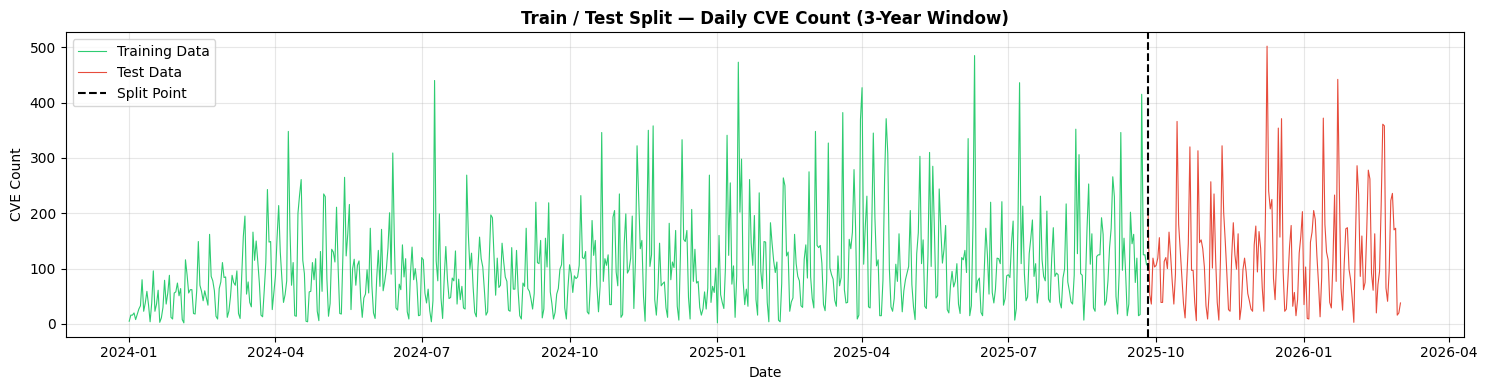

In [5]:
X_all = recent_data[FEATURES].values.astype(np.float32)   # (n_days, 10)
y_all = recent_data['cve_count'].values.astype(np.float32) # (n_days,)

train_size   = int(len(recent_data) * TRAIN_RATIO)
X_train_raw  = X_all[:train_size]
X_test_raw   = X_all[train_size:]
y_train_raw  = y_all[:train_size]
y_test_raw   = y_all[train_size:]

print(f'  Train days : {train_size}  ({TRAIN_RATIO*100:.0f}%)')
print(f'  Test  days : {len(recent_data) - train_size}  ({(1-TRAIN_RATIO)*100:.0f}%)')
print(f'  Features   : {N_FEATURES}')

# Visualise the split
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(recent_data['date'][:train_size], y_train_raw,
        color='#2ECC71', linewidth=0.8, label='Training Data')
ax.plot(recent_data['date'][train_size:], y_test_raw,
        color='#E74C3C', linewidth=0.8, label='Test Data')
ax.axvline(x=recent_data['date'].iloc[train_size],
           color='black', linestyle='--', linewidth=1.5, label='Split Point')
ax.set_title('Train / Test Split — Daily CVE Count (3-Year Window)', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('CVE Count')
ax.legend()
plt.tight_layout()
plt.savefig(P2_DIR / 'p2_00_train_test_split.png', dpi=150, bbox_inches='tight')
plt.show()


---
## ⚖️ Step 5 — Feature Scaling & Sliding-Window Sequences

> **Why two scalers?**  
> `feature_scaler` normalises all 10 input columns (used for model input).  
> `target_scaler` normalises only `cve_count` (used to inverse-transform predictions back to raw CVE counts).  
> Using a single 10-column scaler would make inverse-transforming predictions impossible.

> **Sequence shape:**  Each sample is a `(14, 10)` window — 14 days × 10 features.  
> The target is the scaled `cve_count` at the next day (`look_back + 1`).

> **Split offset:** With `LOOK_BACK=14`, the sequence-safe train split is `train_size - 14`, not `train_size`.  
> Test predictions therefore align to dates starting at `recent_data['date'][train_size + 14]`.


In [6]:
class MultivariatePipeline:
    """
    Handles feature scaling and sliding-window sequence construction
    for all three Phase 2 deep learning models.
    """

    def __init__(self, look_back: int = LOOK_BACK):
        self.look_back      = look_back
        self.feature_scaler = MinMaxScaler()
        self.target_scaler  = MinMaxScaler()

    def fit_transform(self, X, y):
        """Fit scalers on training data and return scaled arrays."""
        X_sc = self.feature_scaler.fit_transform(X)
        y_sc = self.target_scaler.fit_transform(y.reshape(-1, 1)).flatten()
        return X_sc, y_sc

    def transform(self, X, y):
        """Scale test data using already-fitted scalers (no re-fitting)."""
        X_sc = self.feature_scaler.transform(X)
        y_sc = self.target_scaler.transform(y.reshape(-1, 1)).flatten()
        return X_sc, y_sc

    def inverse_target(self, y_scaled):
        """Convert scaled predictions back to raw CVE counts."""
        return self.target_scaler.inverse_transform(
            y_scaled.reshape(-1, 1)
        ).flatten()

    def build_sequences(self, X_scaled, y_scaled):
        """
        Sliding-window sequence builder.
        Returns:
            X_seq : (n_samples, look_back, n_features)
            y_seq : (n_samples,)
        """
        X_seq, y_seq = [], []
        for i in range(len(X_scaled) - self.look_back):
            X_seq.append(X_scaled[i : i + self.look_back])   # (14, 10)
            y_seq.append(y_scaled[i + self.look_back])        # scalar
        return np.array(X_seq, dtype=np.float32), np.array(y_seq, dtype=np.float32)


In [7]:
pipeline = MultivariatePipeline(look_back=LOOK_BACK)

# Fit on train ONLY, transform both
X_train_sc, y_train_sc = pipeline.fit_transform(X_train_raw, y_train_raw)
X_test_sc,  y_test_sc  = pipeline.transform(X_test_raw, y_test_raw)

# Build sequences on the full scaled array, then split
X_all_sc = np.vstack([X_train_sc, X_test_sc])
y_all_sc = np.concatenate([y_train_sc, y_test_sc])
X_seq, y_seq = pipeline.build_sequences(X_all_sc, y_all_sc)

seq_split    = train_size - LOOK_BACK   # ← critical offset
X_seq_train  = X_seq[:seq_split]
X_seq_test   = X_seq[seq_split:]
y_seq_train  = y_seq[:seq_split]
y_seq_test   = y_seq[seq_split:]

# Ground-truth raw counts aligned to the sequence test window
y_test_aligned = pipeline.inverse_target(y_seq_test)
test_dates     = recent_data['date'].values[train_size + LOOK_BACK :]

print(f'  X_seq_train shape : {X_seq_train.shape}  (samples, look_back, features)')
print(f'  X_seq_test  shape : {X_seq_test.shape}')
print(f'  y_seq_train shape : {y_seq_train.shape}')
print(f'  Test dates start  : {pd.Timestamp(test_dates[0]).date()}')

# Sanity check: inverse round-trip
y_rt = pipeline.inverse_target(y_train_sc)
assert np.allclose(y_rt, y_train_raw, rtol=1e-4), 'Scaler round-trip failed!'
print('  Scaler round-trip check passed ✅')


  X_seq_train shape : (618, 14, 10)  (samples, look_back, features)
  X_seq_test  shape : (158, 14, 10)
  y_seq_train shape : (618,)
  Test dates start  : 2025-10-10
  Scaler round-trip check passed ✅


---
## 🔧 Step 6 — Shared Training Utility


All three models use the same `train_model()` function.  

**Improvements over Phase 1:**
| Setting | Phase 1 LSTM | Phase 2 |
|---|---|---|
| Max epochs | 50 | 100 |
| EarlyStopping patience | 10 | 15 |
| ReduceLROnPlateau | ✗ | ✓ patience=7, factor=0.5 |
| Batch size | 16 | 32 |


In [8]:
def train_model(model, X_train, y_train,
                epochs=100, batch_size=32,
                val_split=0.1, patience_es=15, patience_lr=7, verbose=1):
    """
    Train a Keras model with EarlyStopping + ReduceLROnPlateau.
    Returns the History object for loss-curve plotting.
    """
    callbacks = [
        EarlyStopping(
            monitor='val_loss', patience=patience_es,
            restore_best_weights=True, verbose=0
        ),
        ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=patience_lr, min_lr=1e-6, verbose=0
        ),
    ]
    history = model.fit(
        X_train, y_train,
        epochs=epochs, batch_size=batch_size,
        validation_split=val_split,
        callbacks=callbacks, verbose=verbose
    )
    return history


def evaluate(y_true, y_pred, label):
    """Compute MAE, RMSE, MAPE. Clips predictions >= 0 before evaluation."""
    y_pred = np.maximum(y_pred, 0)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1))) * 100
    print(f'\n  {label} Results:')
    print(f'    MAE  : {mae:.4f}')
    print(f'    RMSE : {rmse:.4f}')
    print(f'    MAPE : {mape:.2f}%')
    return {'Model': label, 'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape}


---
## 🧠 Step 7 — Model 1: Multivariate LSTM

**Architecture:**
```
Input  (batch, 14, 10)
LSTM   128 units, return_sequences=True
Dropout 0.2
LSTM   64 units,  return_sequences=False
Dropout 0.2
Dense  32, ReLU
Dense  1   ← predicted next-day CVE count (scaled)
```

Units are doubled vs Phase 1's (64→32) to account for the richer 10-feature input.


In [9]:
def build_multivariate_lstm(look_back, n_features):
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=(look_back, n_features)),
        Dropout(0.2),
        LSTM(64, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ], name='Multivariate_LSTM')
    model.compile(optimizer=Adam(learning_rate=1e-3), loss='mse', metrics=['mae'])
    return model

mv_lstm = build_multivariate_lstm(LOOK_BACK, N_FEATURES)
mv_lstm.summary()


Model: "Multivariate_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 14, 128)        │        71,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,689 (479.25 KB)

 Trainable params: 122,689 (479.25 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
print('Training Multivariate LSTM...')
hist_mvlstm = train_model(mv_lstm, X_seq_train, y_seq_train)

mv_lstm_pred_sc = mv_lstm.predict(X_seq_test, verbose=0).flatten()
mv_lstm_pred    = np.maximum(pipeline.inverse_target(mv_lstm_pred_sc), 0)
mv_lstm_metrics = evaluate(y_test_aligned, mv_lstm_pred, 'Multivariate LSTM')


Training Multivariate LSTM...
Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - loss: 0.0359 - mae: 0.1381 - val_loss: 0.0354 - val_mae: 0.1295 - learning_rate: 0.0010
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0296 - mae: 0.1274 - val_loss: 0.0374 - val_mae: 0.1330 - learning_rate: 0.0010
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0304 - mae: 0.1288 - val_loss: 0.0359 - val_mae: 0.1300 - learning_rate: 0.0010
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0296 - mae: 0.1260 - val_loss: 0.0342 - val_mae: 0.1273 - learning_rate: 0.0010
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0285 - mae: 0.1229 - val_loss: 0.0328 - val_mae: 0.1260 - learning_rate: 0.0010
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0290 - mae: 0.1238 - val_loss: 0.0337 - val_mae: 0.1254 - learning_rate: 0.0010
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.0287 - mae: 0.1249 - val_loss: 0.0350 - val_mae: 0.1267 

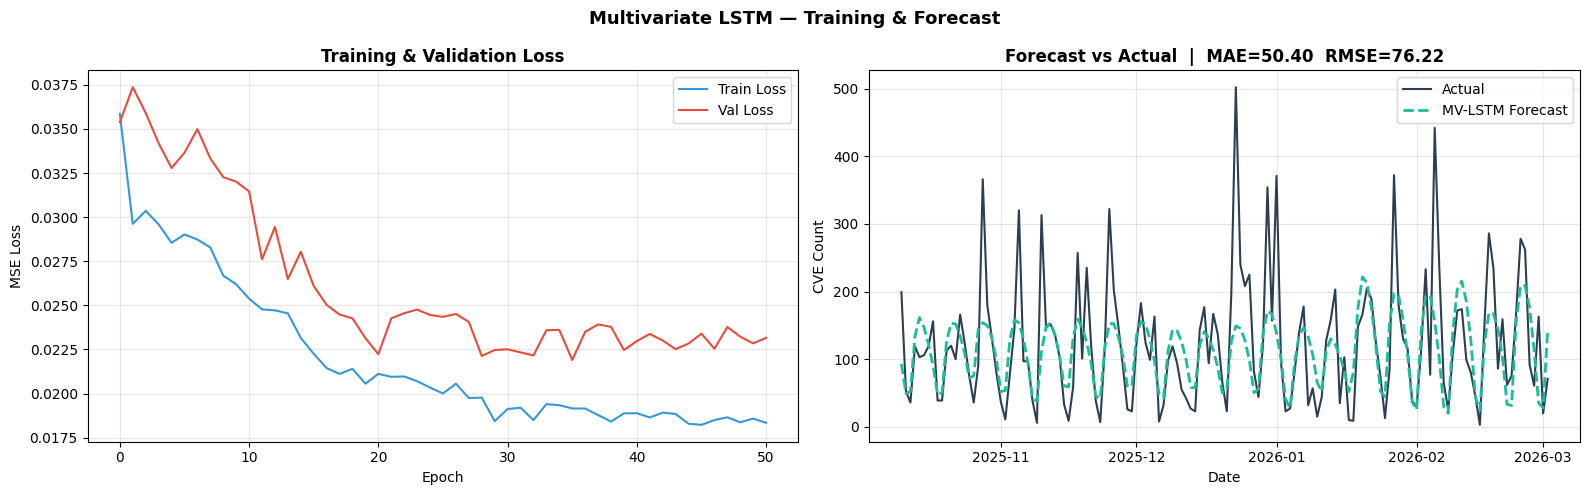

In [11]:
# Plot: training curve + forecast vs actual
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Multivariate LSTM — Training & Forecast', fontsize=13, fontweight='bold')

# Loss curves
axes[0].plot(hist_mvlstm.history['loss'],     label='Train Loss', color='#3498DB', linewidth=1.5)
axes[0].plot(hist_mvlstm.history['val_loss'], label='Val Loss',   color='#E74C3C', linewidth=1.5)
axes[0].set_title('Training & Validation Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()

# Forecast vs actual
min_len = min(len(test_dates), len(mv_lstm_pred))
axes[1].plot(test_dates[:min_len], y_test_aligned[:min_len],
             color=COLORS['actual'], label='Actual', linewidth=1.5)
axes[1].plot(test_dates[:min_len], mv_lstm_pred[:min_len],
             color=COLORS['mv_lstm'], label='MV-LSTM Forecast',
             linewidth=2, linestyle='--')
mae_v  = mv_lstm_metrics['MAE']
rmse_v = mv_lstm_metrics['RMSE']
axes[1].set_title(f'Forecast vs Actual  |  MAE={mae_v:.2f}  RMSE={rmse_v:.2f}', fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('CVE Count')
axes[1].legend()

plt.tight_layout()
plt.savefig(P2_DIR / 'p2_01_mv_lstm.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 🔄 Step 8 — Model 2: BiLSTM (Bidirectional LSTM)

**Architecture:**
```
Input              (batch, 14, 10)
Bidirectional(LSTM 64, seq=True)   → 128 units (forward + backward)
Dropout 0.2
Bidirectional(LSTM 32, seq=False)  → 64 units
Dropout 0.2
Dense 32, ReLU
Dense 1
```

The backward pass lets the model use information from later in the window as context for earlier positions.
For CVE data, this helps capture symmetric patterns like the weekend dip (low Friday → low Saturday → low Monday).


In [12]:
def build_bilstm(look_back, n_features):
    model = Sequential([
        Bidirectional(
            LSTM(64, return_sequences=True),
            input_shape=(look_back, n_features)
        ),
        Dropout(0.2),
        Bidirectional(LSTM(32, return_sequences=False)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ], name='BiLSTM')
    model.compile(optimizer=Adam(learning_rate=1e-3), loss='mse', metrics=['mae'])
    return model

bilstm = build_bilstm(LOOK_BACK, N_FEATURES)
bilstm.summary()


Model: "BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 14, 128)        │        38,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,729 (319.25 KB)

 Trainable params: 81,729 (319.25 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
print('Training BiLSTM...')
hist_bilstm = train_model(bilstm, X_seq_train, y_seq_train)

bilstm_pred_sc = bilstm.predict(X_seq_test, verbose=0).flatten()
bilstm_pred    = np.maximum(pipeline.inverse_target(bilstm_pred_sc), 0)
bilstm_metrics = evaluate(y_test_aligned, bilstm_pred, 'BiLSTM')


Training BiLSTM...
Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 66ms/step - loss: 0.0304 - mae: 0.1289 - val_loss: 0.0311 - val_mae: 0.1313 - learning_rate: 0.0010
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0285 - mae: 0.1238 - val_loss: 0.0292 - val_mae: 0.1258 - learning_rate: 0.0010
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0266 - mae: 0.1172 - val_loss: 0.0279 - val_mae: 0.1276 - learning_rate: 0.0010
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0250 - mae: 0.1139 - val_loss: 0.0260 - val_mae: 0.1194 - learning_rate: 0.0010
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0246 - mae: 0.1124 - val_loss: 0.0245 - val_mae: 0.1179 - learning_rate: 0.0010
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0226 - mae: 0.1069 - val_loss: 0.0233 - val_mae: 0.1139 - learning_rate: 0.0010
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0220 - mae: 0.1050 - val_loss: 0.0225 - val_mae: 0.1088 - learning_

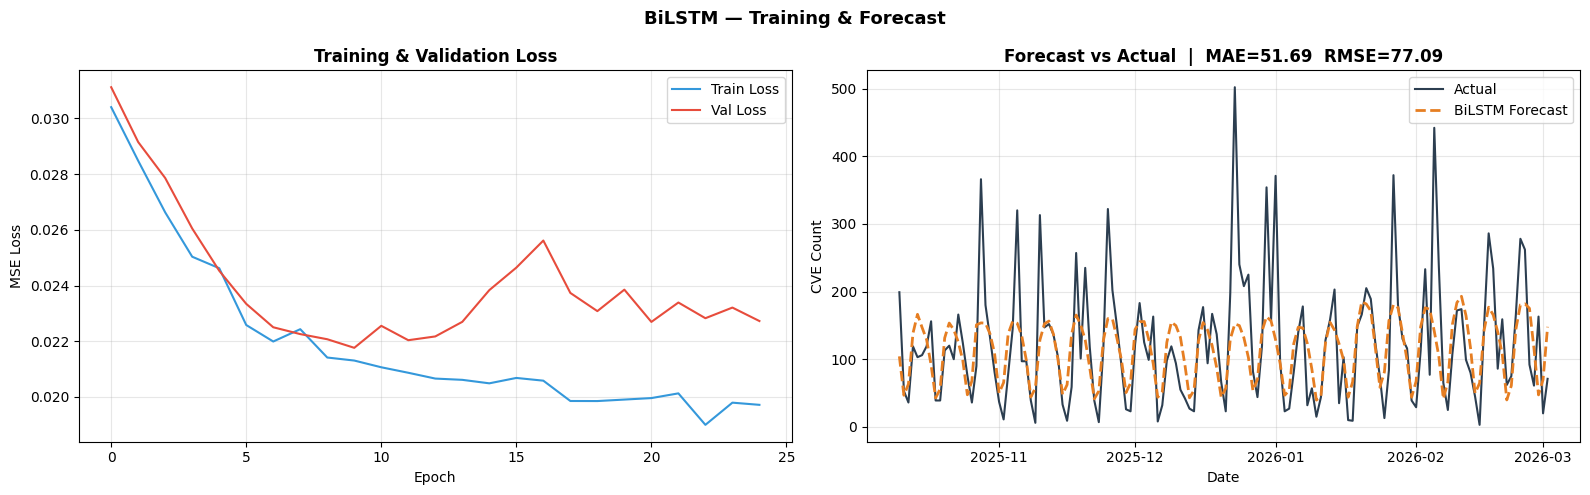

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('BiLSTM — Training & Forecast', fontsize=13, fontweight='bold')

axes[0].plot(hist_bilstm.history['loss'],     label='Train Loss', color='#3498DB', linewidth=1.5)
axes[0].plot(hist_bilstm.history['val_loss'], label='Val Loss',   color='#E74C3C', linewidth=1.5)
axes[0].set_title('Training & Validation Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()

min_len = min(len(test_dates), len(bilstm_pred))
axes[1].plot(test_dates[:min_len], y_test_aligned[:min_len],
             color=COLORS['actual'], label='Actual', linewidth=1.5)
axes[1].plot(test_dates[:min_len], bilstm_pred[:min_len],
             color=COLORS['bilstm'], label='BiLSTM Forecast',
             linewidth=2, linestyle='--')
mae_v  = bilstm_metrics['MAE']
rmse_v = bilstm_metrics['RMSE']
axes[1].set_title(f'Forecast vs Actual  |  MAE={mae_v:.2f}  RMSE={rmse_v:.2f}', fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('CVE Count')
axes[1].legend()

plt.tight_layout()
plt.savefig(P2_DIR / 'p2_02_bilstm.png', dpi=150, bbox_inches='tight')
plt.show()


---
## ⚡ Step 9 — Model 3: Transformer

**Architecture:**
```
Input                    (batch, 14, 10)
Dense(32)                feature projection → d_model = 32
─── TransformerBlock × 2 ──────────────────────────────────────
  MultiHeadAttention(4 heads, key_dim=16)
  Add + LayerNorm
  FFN: Dense(64, ReLU) → Dense(32)
  Add + LayerNorm
────────────────────────────────────────────────────────────────
GlobalAveragePooling1D   collapse the 14-step dimension
Dense(32, ReLU)
Dropout(0.1)
Dense(1)
```

> **Why no positional encoding?** The `FEATURES` list already contains strong
> temporal position signals (`day_of_week`, `day_of_year`, `week_of_year`).
> Adding a separate sinusoidal PE on top would be redundant.

> **Why Dense(32) projection?** The residual `Add` inside each Transformer block
> requires all tensors to have the same depth. Projecting 10 → 32 (`d_model`)
> before the first block ensures this consistency throughout.


In [15]:
def transformer_encoder_block(inputs, num_heads, key_dim, ff_dim, dropout_rate=0.1):
    """Single Transformer encoder block: MHA → Add+LN → FFN → Add+LN."""
    # Multi-head self-attention
    attn = MultiHeadAttention(
        num_heads=num_heads, key_dim=key_dim, dropout=dropout_rate
    )(inputs, inputs)
    attn  = Dropout(dropout_rate)(attn)
    out1  = LayerNormalization(epsilon=1e-6)(inputs + attn)   # residual

    # Position-wise feed-forward network
    ffn   = Dense(ff_dim, activation='relu')(out1)
    ffn   = Dense(inputs.shape[-1])(ffn)                      # project back to d_model
    ffn   = Dropout(dropout_rate)(ffn)
    out2  = LayerNormalization(epsilon=1e-6)(out1 + ffn)      # residual
    return out2


def build_transformer(look_back, n_features,
                       num_heads=4, key_dim=16, ff_dim=64,
                       n_blocks=2, dropout_rate=0.1):
    d_model = 32
    inp = Input(shape=(look_back, n_features), name='input')
    x   = Dense(d_model, name='feature_projection')(inp)   # (batch, 14, 32)

    for _ in range(n_blocks):
        x = transformer_encoder_block(x, num_heads, key_dim, ff_dim, dropout_rate)

    x   = GlobalAveragePooling1D(name='global_avg_pool')(x) # (batch, 32)
    x   = Dense(32, activation='relu', name='head_dense')(x)
    x   = Dropout(dropout_rate)(x)
    out = Dense(1, name='output')(x)

    model = Model(inputs=inp, outputs=out, name='Transformer')
    model.compile(
        optimizer=Adam(learning_rate=5e-4),   # lower LR for stability
        loss='mse', metrics=['mae']
    )
    return model

transformer = build_transformer(LOOK_BACK, N_FEATURES)
transformer.summary()


Model: "Transformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 14, 10)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_projection  │ (None, 14, 32)    │        352 │ input[0][0]       │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 14, 32)    │      8,416 │ feature_projecti… │
│ (MultiHeadAttentio… │                   │            │ feature_projecti… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 14, 32)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 14, 32)    │          0 │ feature_projecti… │
│                     │                   │            │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 14, 32)    │         64 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 14, 64)    │      2,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 14, 32)    │      2,080 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 14, 32)    │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 14, 32)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 14, 32)    │         64 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 14, 32)    │      8,416 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 14, 32)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 14, 32)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 14, 32)    │         64 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 14, 64)    │      2,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 14, 32)    │      2,080 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 14, 32)    │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 14, 32)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 14, 32)    │         64 │ add_3[0][0]     

 Total params: 26,913 (105.13 KB)

 Trainable params: 26,913 (105.13 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
print('Training Transformer...')
hist_transformer = train_model(transformer, X_seq_train, y_seq_train)

transformer_pred_sc = transformer.predict(X_seq_test, verbose=0).flatten()
transformer_pred    = np.maximum(pipeline.inverse_target(transformer_pred_sc), 0)
transformer_metrics = evaluate(y_test_aligned, transformer_pred, 'Transformer')


Training Transformer...
Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 66ms/step - loss: 0.1283 - mae: 0.2808 - val_loss: 0.0482 - val_mae: 0.1536 - learning_rate: 5.0000e-04
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0445 - mae: 0.1654 - val_loss: 0.0464 - val_mae: 0.1512 - learning_rate: 5.0000e-04
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0389 - mae: 0.1505 - val_loss: 0.0344 - val_mae: 0.1311 - learning_rate: 5.0000e-04
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0337 - mae: 0.1341 - val_loss: 0.0337 - val_mae: 0.1357 - learning_rate: 5.0000e-04
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0342 - mae: 0.1365 - val_loss: 0.0338 - val_mae: 0.1304 - learning_rate: 5.0000e-04
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0315 - mae: 0.1308 - val_loss: 0.0343 - val_mae: 0.1325 - learning_rate: 5.0000e-04
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0308 - mae: 0.1298 - val_loss: 0.0342

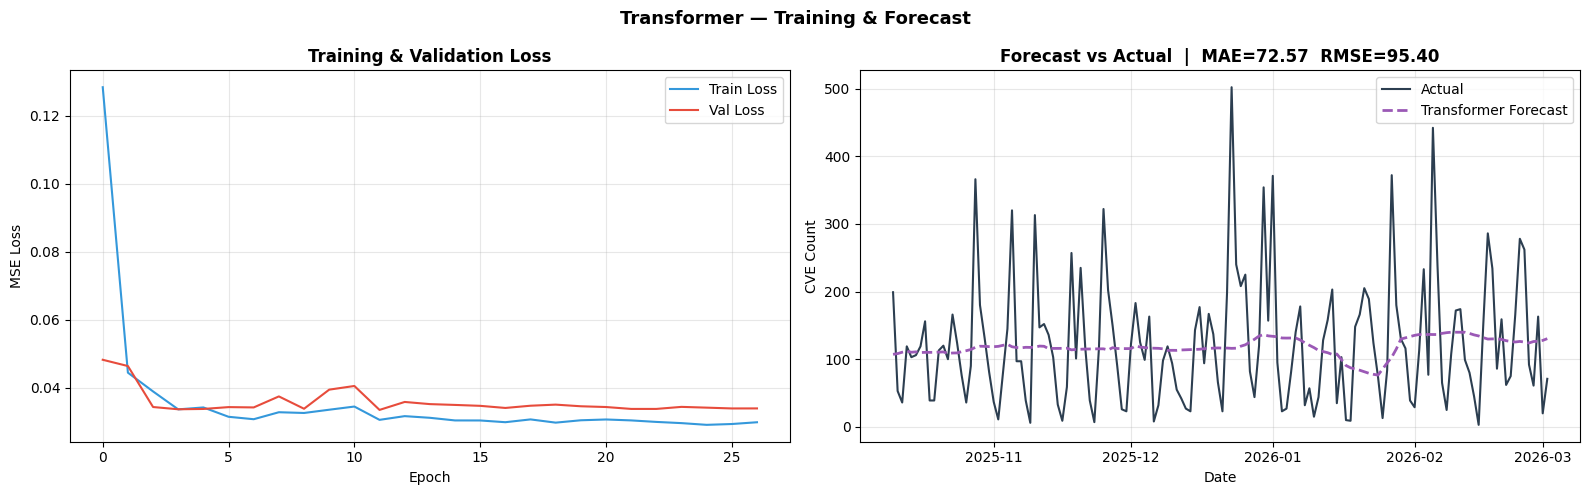

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Transformer — Training & Forecast', fontsize=13, fontweight='bold')

axes[0].plot(hist_transformer.history['loss'],     label='Train Loss', color='#3498DB', linewidth=1.5)
axes[0].plot(hist_transformer.history['val_loss'], label='Val Loss',   color='#E74C3C', linewidth=1.5)
axes[0].set_title('Training & Validation Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()

min_len = min(len(test_dates), len(transformer_pred))
axes[1].plot(test_dates[:min_len], y_test_aligned[:min_len],
             color=COLORS['actual'], label='Actual', linewidth=1.5)
axes[1].plot(test_dates[:min_len], transformer_pred[:min_len],
             color=COLORS['transformer'], label='Transformer Forecast',
             linewidth=2, linestyle='--')
mae_v  = transformer_metrics['MAE']
rmse_v = transformer_metrics['RMSE']
axes[1].set_title(f'Forecast vs Actual  |  MAE={mae_v:.2f}  RMSE={rmse_v:.2f}', fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('CVE Count')
axes[1].legend()

plt.tight_layout()
plt.savefig(P2_DIR / 'p2_03_transformer.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 📉 Step 10 — Combined Training Loss Curves


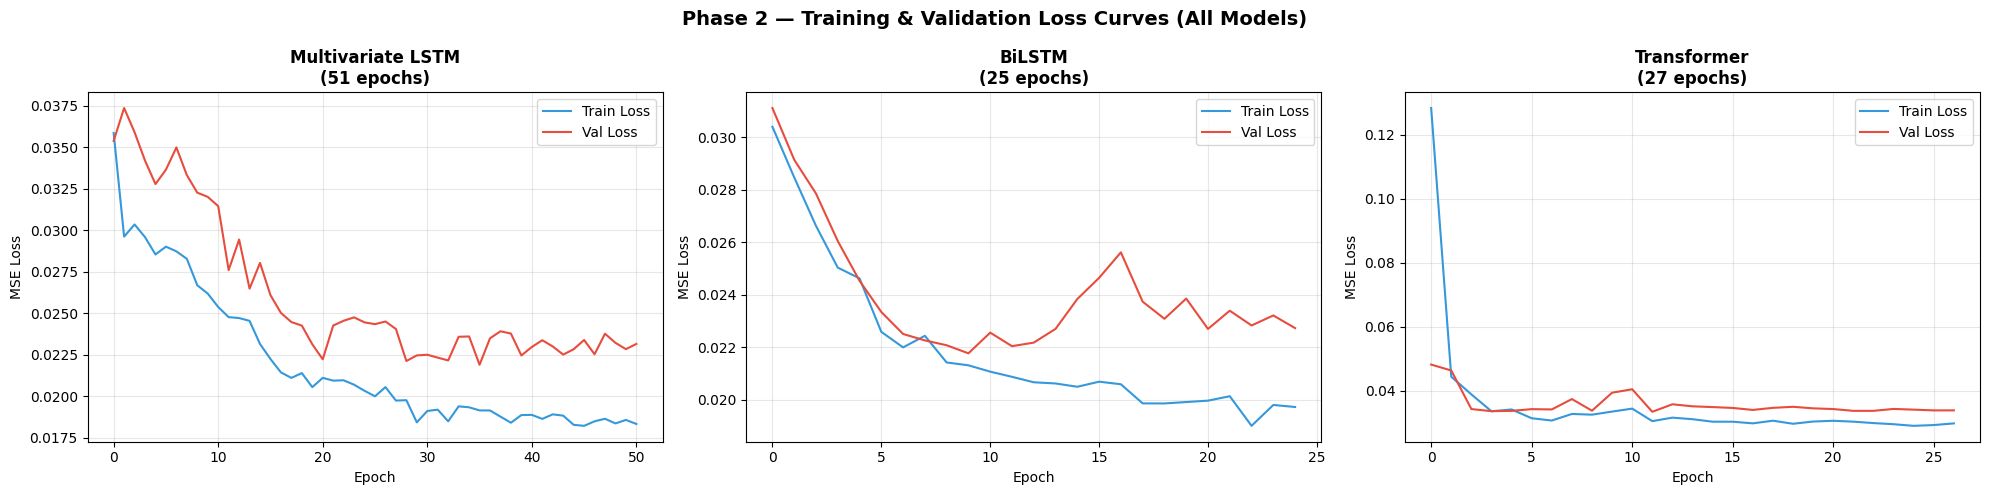

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Phase 2 — Training & Validation Loss Curves (All Models)',
             fontsize=14, fontweight='bold')

histories = {
    'Multivariate LSTM': (hist_mvlstm,     COLORS['mv_lstm']),
    'BiLSTM'           : (hist_bilstm,     COLORS['bilstm']),
    'Transformer'      : (hist_transformer, COLORS['transformer']),
}

for ax, (name, (hist, color)) in zip(axes, histories.items()):
    ax.plot(hist.history['loss'],     color='#3498DB', linewidth=1.5, label='Train Loss')
    ax.plot(hist.history['val_loss'], color='#E74C3C', linewidth=1.5, label='Val Loss')
    stopped_at = len(hist.history['loss'])
    ax.set_title(f'{name}\n({stopped_at} epochs)', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()

plt.tight_layout()
plt.savefig(P2_DIR / 'p2_04_loss_curves_all.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 📊 Step 11 — Phase 2 Results & Combined Comparison


In [19]:
# ── Phase 2 standalone results
p2_results = pd.DataFrame([mv_lstm_metrics, bilstm_metrics, transformer_metrics])
p2_results['Phase'] = 'Phase 2'
p2_results = p2_results.sort_values('RMSE').reset_index(drop=True)
p2_results['Rank'] = p2_results.index + 1

print('='*60)
print('  PHASE 2 MODEL COMPARISON (sorted by RMSE)')
print('='*60)
print(p2_results[['Rank', 'Model', 'MAE', 'RMSE', 'MAPE (%)']].to_string(index=False))

best_p2_name = p2_results.iloc[0]['Model']
best_p2_rmse = p2_results.iloc[0]['RMSE']
print(f'\n  Best Phase 2 Model : {best_p2_name}  (RMSE = {best_p2_rmse:.4f})')

# ── Load Phase 1 results and merge
p1_csv = OUTPUT_DIR / 'model_results.csv'
if p1_csv.exists():
    p1_results = pd.read_csv(p1_csv)
    p1_results['Model'] = p1_results['Model'].replace({'LSTM': 'LSTM (P1)'})
    p1_results['Phase'] = 'Phase 1'
    all_results = pd.concat([p1_results, p2_results], ignore_index=True)
    all_results = all_results.sort_values('RMSE').reset_index(drop=True)
    all_results['Overall Rank'] = all_results.index + 1
    print('\n' + '='*60)
    print('  COMBINED PHASE 1 + PHASE 2 RANKING (by RMSE)')
    print('='*60)
    print(all_results[['Overall Rank', 'Phase', 'Model', 'MAE', 'RMSE', 'MAPE (%)']].to_string(index=False))
else:
    print('\n  Phase 1 model_results.csv not found — showing Phase 2 only.')
    all_results = p2_results

display(all_results.style.highlight_min(subset=['RMSE'], color='#d4edda'))


  PHASE 2 MODEL COMPARISON (sorted by RMSE)
 Rank             Model       MAE      RMSE   MAPE (%)
    1 Multivariate LSTM 50.398365 76.223157  75.115128
    2            BiLSTM 51.691742 77.085848  90.406433
    3       Transformer 72.570274 95.404674 177.387787

  Best Phase 2 Model : Multivariate LSTM  (RMSE = 76.2232)

  Phase 1 model_results.csv not found — showing Phase 2 only.


,Model,MAE,RMSE,MAPE (%),Phase,Rank
0,Multivariate LSTM,50.398365,76.223157,75.115128,Phase 2,1
1,BiLSTM,51.691742,77.085848,90.406433,Phase 2,2
2,Transformer,72.570274,95.404674,177.387787,Phase 2,3


---
## 📈 Step 12 — Full Comparison Dashboard


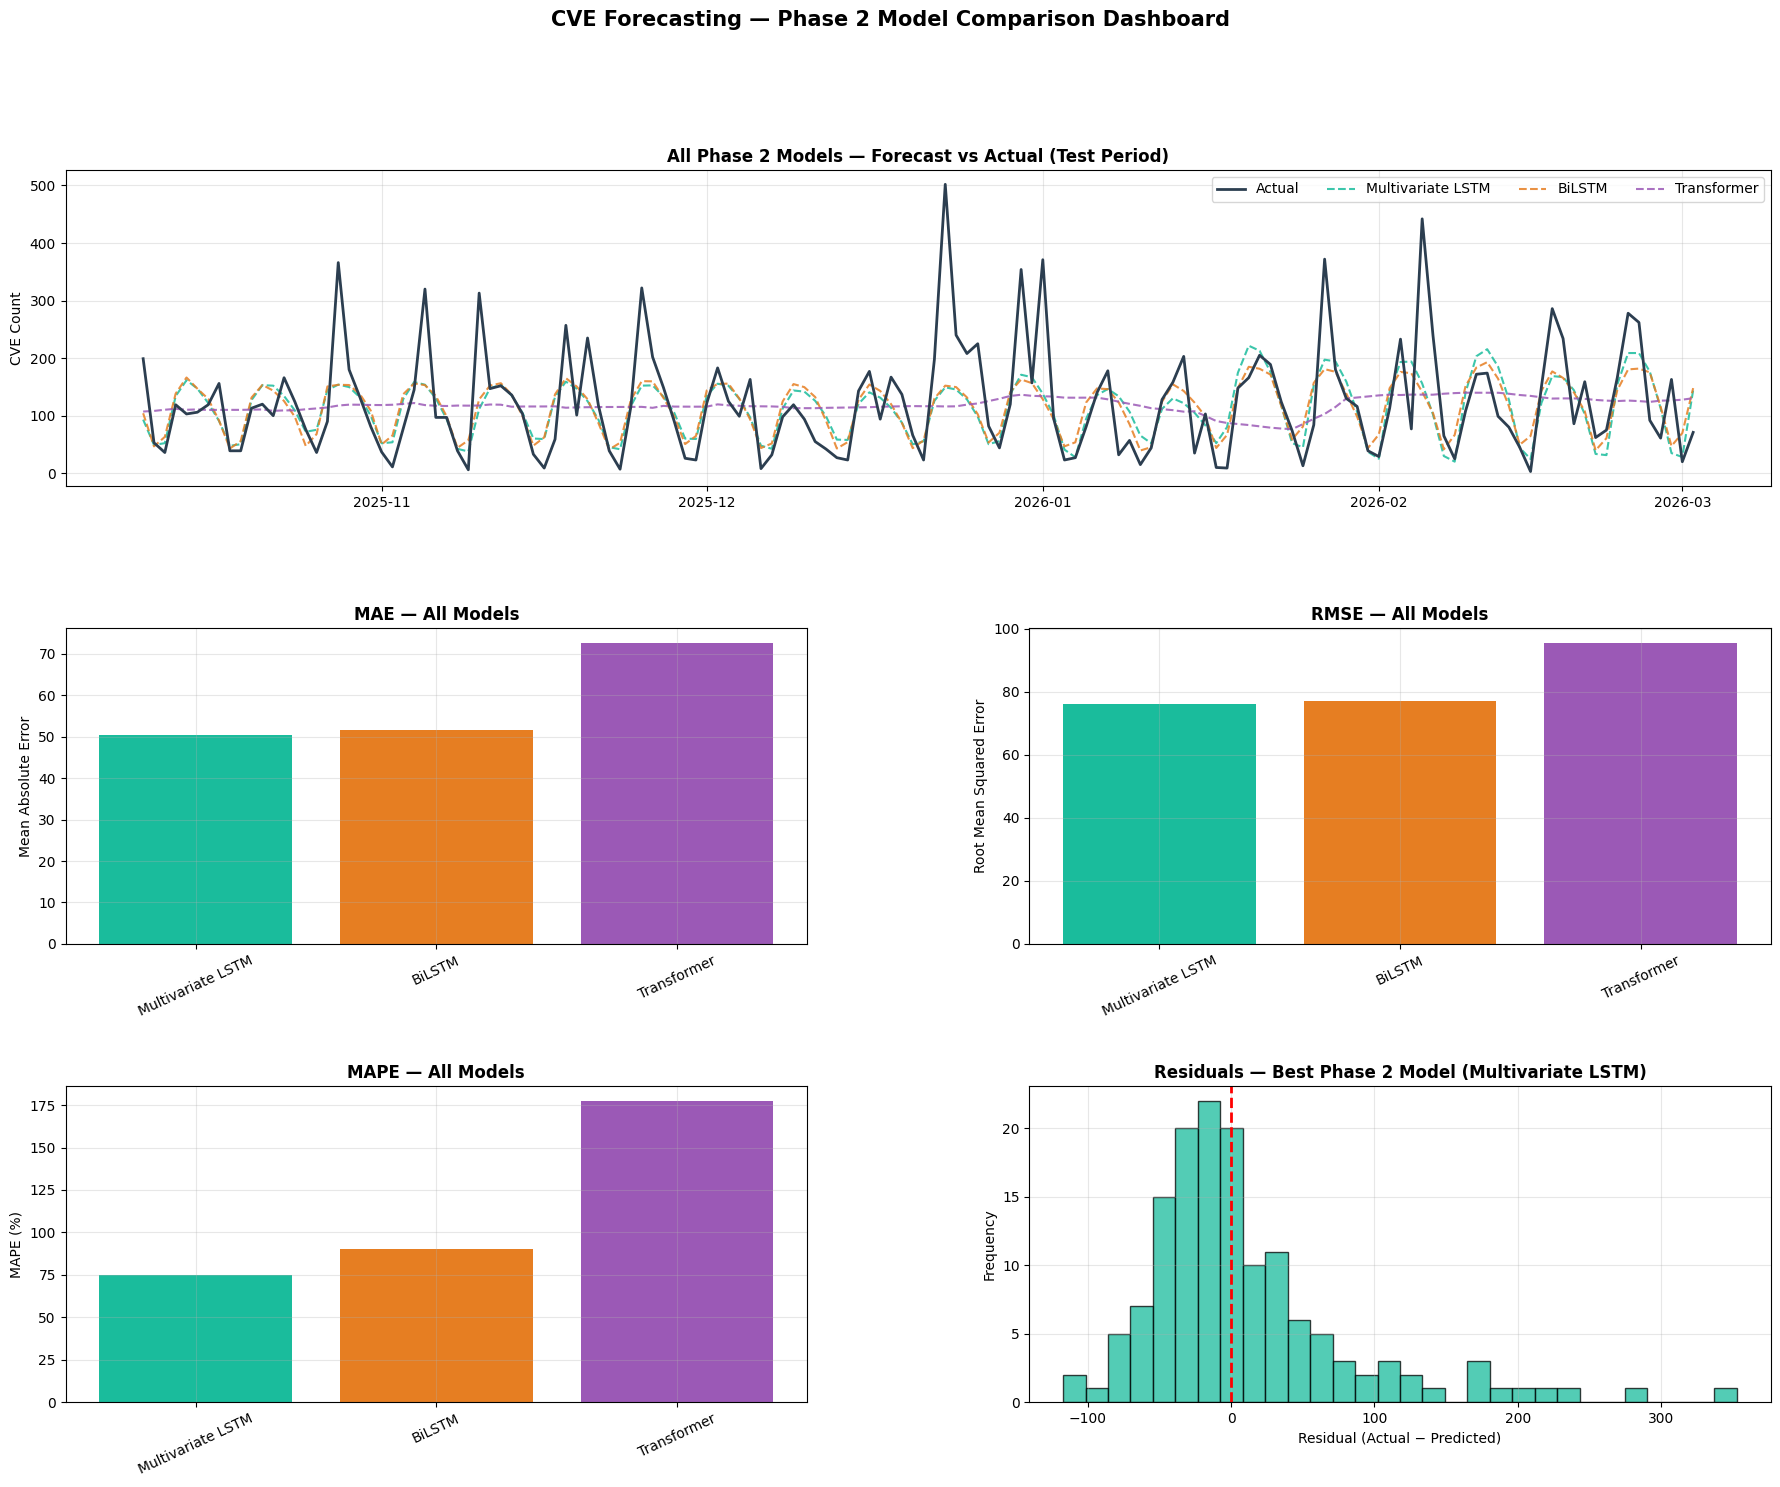

In [20]:
# Align all predictions to the same length
min_len = min(len(test_dates),
              len(mv_lstm_pred), len(bilstm_pred), len(transformer_pred))
t_dates  = test_dates[:min_len]
y_actual = y_test_aligned[:min_len]

p2_color_map = {
    'Multivariate LSTM': COLORS['mv_lstm'],
    'BiLSTM'           : COLORS['bilstm'],
    'Transformer'      : COLORS['transformer'],
}
p2_preds = {
    'Multivariate LSTM': mv_lstm_pred[:min_len],
    'BiLSTM'           : bilstm_pred[:min_len],
    'Transformer'      : transformer_pred[:min_len],
}

fig = plt.figure(figsize=(22, 16))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.3)
fig.suptitle('CVE Forecasting — Phase 2 Model Comparison Dashboard',
             fontsize=15, fontweight='bold')

# Panel 1: All predictions vs actual
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(t_dates, y_actual, color=COLORS['actual'],
         label='Actual', linewidth=2, zorder=10)
for name, pred in p2_preds.items():
    ax1.plot(t_dates, pred, color=p2_color_map[name],
             label=name, linewidth=1.5, linestyle='--', alpha=0.85)
ax1.set_title('All Phase 2 Models — Forecast vs Actual (Test Period)', fontweight='bold')
ax1.set_ylabel('CVE Count')
ax1.legend(loc='upper right', ncol=4)

models_sorted = all_results.sort_values('RMSE')['Model'].tolist()
all_color_map = {
    **p2_color_map,
    'ARIMA(5,1,0)' : COLORS['arima'],
    'Random Forest': COLORS['rf'],
    'XGBoost'      : COLORS['xgb'],
    'SVR (RBF)'    : COLORS['svr'],
    'LSTM (P1)'    : COLORS['lstm_p1'],
}
bar_colors = [all_color_map.get(m, '#888') for m in models_sorted]

# Panel 2: MAE
ax2 = fig.add_subplot(gs[1, 0])
mae_vals = [all_results.set_index('Model').loc[m, 'MAE'] for m in models_sorted]
ax2.bar(models_sorted, mae_vals, color=bar_colors)
ax2.set_title('MAE — All Models', fontweight='bold')
ax2.set_ylabel('Mean Absolute Error')
ax2.tick_params(axis='x', rotation=25)

# Panel 3: RMSE
ax3 = fig.add_subplot(gs[1, 1])
rmse_vals = [all_results.set_index('Model').loc[m, 'RMSE'] for m in models_sorted]
ax3.bar(models_sorted, rmse_vals, color=bar_colors)
ax3.set_title('RMSE — All Models', fontweight='bold')
ax3.set_ylabel('Root Mean Squared Error')
ax3.tick_params(axis='x', rotation=25)

# Panel 4: MAPE
ax4 = fig.add_subplot(gs[2, 0])
mape_vals = [all_results.set_index('Model').loc[m, 'MAPE (%)'] for m in models_sorted]
ax4.bar(models_sorted, mape_vals, color=bar_colors)
ax4.set_title('MAPE — All Models', fontweight='bold')
ax4.set_ylabel('MAPE (%)')
ax4.tick_params(axis='x', rotation=25)

# Panel 5: Residuals for best Phase 2 model
ax5 = fig.add_subplot(gs[2, 1])
best_pred = p2_preds[best_p2_name]
residuals = y_actual - best_pred
ax5.hist(residuals, bins=30, color=p2_color_map[best_p2_name], alpha=0.75, edgecolor='black')
ax5.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax5.set_title(f'Residuals — Best Phase 2 Model ({best_p2_name})', fontweight='bold')
ax5.set_xlabel('Residual (Actual − Predicted)')
ax5.set_ylabel('Frequency')

plt.savefig(P2_DIR / 'p2_05_comparison_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 🔮 Step 13 — 30-Day Future Forecast

**Iterative multivariate forecasting strategy:**
1. Feed the current `(1, 14, 10)` window → predict next scaled CVE count
2. Inverse-transform → raw count; clip to ≥ 0
3. Append raw count to `raw_history`
4. Build next day's 10-feature row using date arithmetic + `raw_history` for rolling/lag
5. Scale the new row; slide the window forward
6. Repeat for 30 steps


In [21]:
def forecast_30_days(model, pipeline, recent_data, last_date):
    """Generate a 30-day iterative multivariate forecast."""
    future_dates = pd.date_range(last_date + timedelta(days=1), periods=30, freq='D')
    future_preds = []

    # Seed: last LOOK_BACK scaled feature rows
    X_all_sc_full = np.vstack([
        pipeline.feature_scaler.transform(X_train_raw),
        pipeline.feature_scaler.transform(X_test_raw)
    ])
    window = X_all_sc_full[-LOOK_BACK:].copy()    # (14, 10)

    # Raw history for computing rolling/lag features
    raw_history = list(recent_data['cve_count'].values[-LOOK_BACK:])

    for fd in future_dates:
        # Predict
        x_in     = window.reshape(1, LOOK_BACK, N_FEATURES)
        pred_sc  = model.predict(x_in, verbose=0)[0, 0]
        pred_raw = float(pipeline.inverse_target(np.array([pred_sc]))[0])
        pred_raw = max(pred_raw, 0)
        future_preds.append(pred_raw)
        raw_history.append(pred_raw)

        # Build next-day feature row (unscaled)
        new_row = np.array([
            fd.dayofweek,
            fd.month,
            fd.dayofyear,
            int(fd.isocalendar()[1]),
            int(fd.dayofweek >= 5),
            fd.quarter,
            float(np.mean(raw_history[-7:])),
            float(np.mean(raw_history[-14:])),
            raw_history[-1],
            raw_history[-7] if len(raw_history) >= 7 else raw_history[0],
        ], dtype=np.float32)

        new_row_sc = pipeline.feature_scaler.transform(new_row.reshape(1, -1))[0]
        window = np.vstack([window[1:], new_row_sc])   # slide

    return pd.DataFrame({
        'Date'          : future_dates,
        'Predicted_CVEs': [round(p, 1) for p in future_preds]
    })


# Run with best Phase 2 model
best_model_obj = {
    'Multivariate LSTM': mv_lstm,
    'BiLSTM'           : bilstm,
    'Transformer'      : transformer,
}[best_p2_name]

last_date   = recent_data['date'].max()
forecast_df = forecast_30_days(best_model_obj, pipeline, recent_data, last_date)

print(f'  30-Day CVE Forecast using: {best_p2_name}')
print(forecast_df.to_string(index=False))


  30-Day CVE Forecast using: Multivariate LSTM
      Date  Predicted_CVEs
2026-03-03           178.6
2026-03-04           176.3
2026-03-05           147.6
2026-03-06           102.1
2026-03-07            34.0
2026-03-08            23.8
2026-03-09           124.4
2026-03-10           174.1
2026-03-11           184.1
2026-03-12           158.2
2026-03-13           108.9
2026-03-14            40.2
2026-03-15            44.2
2026-03-16           154.0
2026-03-17           189.3
2026-03-18           179.8
2026-03-19           146.8
2026-03-20            96.8
2026-03-21            33.6
2026-03-22            40.5
2026-03-23           148.8
2026-03-24           178.1
2026-03-25           173.4
2026-03-26           143.0
2026-03-27            96.3
2026-03-28            33.4
2026-03-29            42.0
2026-03-30           143.7
2026-03-31           173.8
2026-04-01           170.7


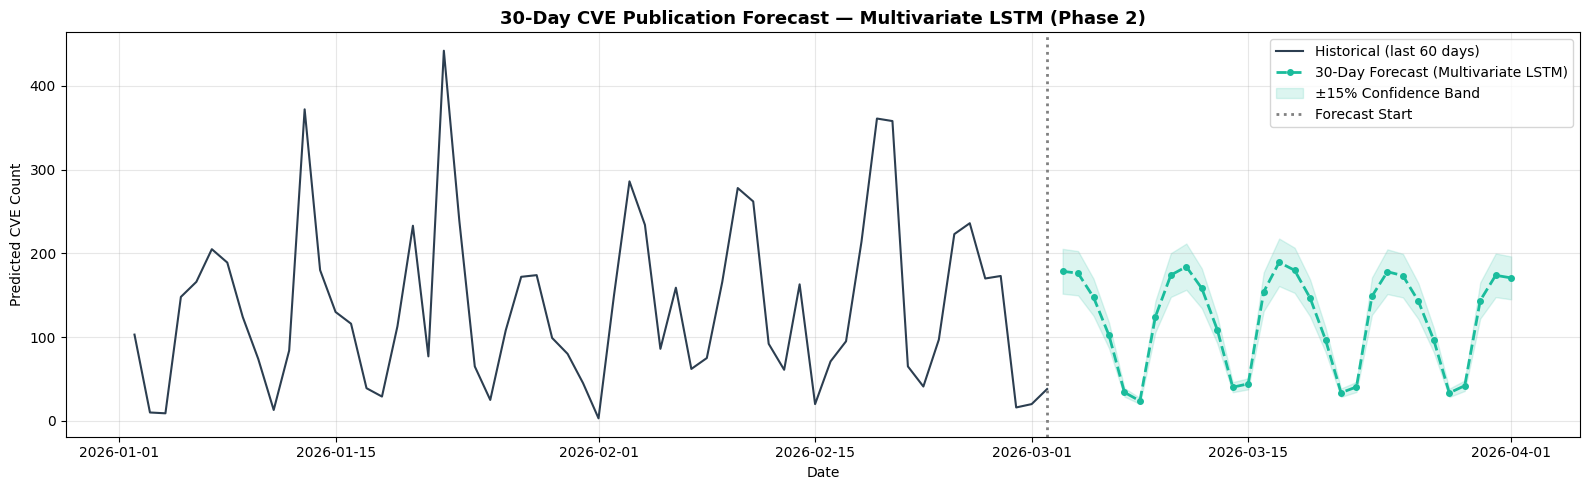

In [22]:
# Plot 30-day forecast
best_color = {
    'Multivariate LSTM': COLORS['mv_lstm'],
    'BiLSTM'           : COLORS['bilstm'],
    'Transformer'      : COLORS['transformer'],
}[best_p2_name]

hist_window = 60
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(recent_data['date'].tail(hist_window),
        recent_data['cve_count'].tail(hist_window),
        color=COLORS['actual'], label=f'Historical (last {hist_window} days)', linewidth=1.5)
ax.plot(forecast_df['Date'], forecast_df['Predicted_CVEs'],
        color=best_color, label=f'30-Day Forecast ({best_p2_name})',
        linewidth=2, linestyle='--', marker='o', markersize=4)
ax.fill_between(
    forecast_df['Date'],
    forecast_df['Predicted_CVEs'] * 0.85,
    forecast_df['Predicted_CVEs'] * 1.15,
    alpha=0.15, color=best_color, label='±15% Confidence Band'
)
ax.axvline(x=last_date, color='gray', linestyle=':', linewidth=2, label='Forecast Start')
ax.set_title(f'30-Day CVE Publication Forecast — {best_p2_name} (Phase 2)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Predicted CVE Count')
ax.legend()
plt.tight_layout()
plt.savefig(P2_DIR / 'p2_06_30day_forecast.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 💾 Step 14 — Save All Outputs


In [23]:
# ── CSVs
p2_results.to_csv(P2_DIR / 'phase2_model_results.csv', index=False)
print(f'  Phase 2 results     → {P2_DIR}/phase2_model_results.csv')

if 'Overall Rank' in all_results.columns:
    all_results.to_csv(P2_DIR / 'all_phases_model_results.csv', index=False)
    print(f'  Combined results    → {P2_DIR}/all_phases_model_results.csv')

forecast_df.to_csv(P2_DIR / 'phase2_30day_forecast.csv', index=False)
print(f'  30-day forecast     → {P2_DIR}/phase2_30day_forecast.csv')

# ── Keras models
mv_lstm.save(P2_DIR     / 'mv_lstm_model.keras')
bilstm.save(P2_DIR      / 'bilstm_model.keras')
transformer.save(P2_DIR / 'transformer_model.keras')
print(f'  Keras models saved  → {P2_DIR}/')
print()
print('  Output files in phase2/:')
for f in sorted(P2_DIR.iterdir()):
    print(f'    {f.name}')


  Phase 2 results     → C:\Users\imved\OneDrive\Desktop\cysecc\cybersec-ind\baseline_outputs\phase2/phase2_model_results.csv
  30-day forecast     → C:\Users\imved\OneDrive\Desktop\cysecc\cybersec-ind\baseline_outputs\phase2/phase2_30day_forecast.csv
  Keras models saved  → C:\Users\imved\OneDrive\Desktop\cysecc\cybersec-ind\baseline_outputs\phase2/

  Output files in phase2/:
    bilstm_model.keras
    mv_lstm_model.keras
    p2_00_train_test_split.png
    p2_01_mv_lstm.png
    p2_02_bilstm.png
    p2_03_transformer.png
    p2_04_loss_curves_all.png
    p2_05_comparison_dashboard.png
    p2_06_30day_forecast.png
    phase2_30day_forecast.csv
    phase2_model_results.csv
    transformer_model.keras


---
## 🏁 Step 15 — Phase 2 Complete Summary


In [24]:
print('\n' + '='*65)
print('   PHASE 2 — COMPLETE SUMMARY')
print('='*65)
print(f'\n  Data window   : {recent_data["date"].min().date()} → {recent_data["date"].max().date()}')
print(f'  Train / Test  : {train_size} / {len(recent_data) - train_size} days')
print(f'  Lookback      : {LOOK_BACK} days | Features: {N_FEATURES}')
print()
print('  Phase 2 Results (sorted by RMSE):')
print(p2_results[['Rank', 'Model', 'MAE', 'RMSE', 'MAPE (%)']].to_string(index=False))
print()
print(f'  Best Phase 2 Model : {best_p2_name}')
print()
if 'Overall Rank' in all_results.columns:
    overall_best = all_results.iloc[0]
    print(f'  Overall Best (P1+P2): {overall_best["Model"]}  '
          f'(RMSE={overall_best["RMSE"]:.4f}, Phase {overall_best["Phase"][-1]})')
print()
print('  Outputs saved to:', P2_DIR)
print()
print('  Roadmap:')
print('    Phase 1 — Baseline (ARIMA, RF, XGBoost, SVR, LSTM)         ✅ Done')
print('    Phase 2 — Deep Learning (MV-LSTM, BiLSTM, Transformer)     ✅ Done')
print('    Phase 3 — Graph Neural Network (B-MTGNN)                   🔜 Next')
print('    Phase 4 — Threat-Defence Gap + Power BI Dashboard          🔜 Planned')
print('='*65)



   PHASE 2 — COMPLETE SUMMARY

  Data window   : 2024-01-01 → 2026-03-02
  Train / Test  : 632 / 158 days
  Lookback      : 14 days | Features: 10

  Phase 2 Results (sorted by RMSE):
 Rank             Model       MAE      RMSE   MAPE (%)
    1 Multivariate LSTM 50.398365 76.223157  75.115128
    2            BiLSTM 51.691742 77.085848  90.406433
    3       Transformer 72.570274 95.404674 177.387787

  Best Phase 2 Model : Multivariate LSTM


  Outputs saved to: C:\Users\imved\OneDrive\Desktop\cysecc\cybersec-ind\baseline_outputs\phase2

  Roadmap:
    Phase 1 — Baseline (ARIMA, RF, XGBoost, SVR, LSTM)         ✅ Done
    Phase 2 — Deep Learning (MV-LSTM, BiLSTM, Transformer)     ✅ Done
    Phase 3 — Graph Neural Network (B-MTGNN)                   🔜 Next
    Phase 4 — Threat-Defence Gap + Power BI Dashboard          🔜 Planned
